<a href="https://colab.research.google.com/github/bhoomikarana90-eng/Employee-salary-predictor-/blob/main/ShortProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# STEP 1: GENERATE THE DATASET
# ==========================================
# Fixing the seed ensures the random numbers are the exact same every time
np.random.seed(42)
n_samples = 200

# Generating independent features for 200 employees
years_experience = np.random.uniform(0, 15, n_samples)
job_tier = np.random.choice([1, 2, 3], size=n_samples, p=[0.5, 0.3, 0.2])       # 1=Junior, 2=Mid, 3=Senior
education_level = np.random.choice([0, 1, 2], size=n_samples, p=[0.4, 0.4, 0.2]) # 0=Bachelor, 1=Master, 2=PhD

# Generating target salary with some realistic randomness (noise)
base_salary = 40000
salary = (
    base_salary
    + (years_experience * 3500)
    + (job_tier * 15000)
    + (education_level * 8000)
    + np.random.normal(0, 4000, n_samples)
)

# Putting it all together into a clean table structure
df = pd.DataFrame({
    'YearsExperience': years_experience,
    'JobTier': job_tier,
    'EducationLevel': education_level,
    'Salary': salary
})

# Display a preview of the first 5 rows in the console
print("=== DATASET PREVIEW ===")
print(df.head())
print("-" * 50)

# ==========================================
# STEP 2: SPLIT INTO TRAIN & TEST SETS
# ==========================================
# X contains input features, y contains what we want to predict
X = df[['YearsExperience', 'JobTier', 'EducationLevel']]
y = df['Salary']

# Reserving 20% of data for evaluating performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# STEP 3: TRAIN THE MODEL
# ==========================================
model = LinearRegression()
model.fit(X_train, y_train)

# ==========================================
# STEP 4: PREDICT & EVALUATE
# ==========================================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== MODEL PERFORMANCE METRICS ===")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R²) Accuracy Score: {r2:.4f}")
print("-" * 50)

print("=== MATHEMATICAL WEIGHTS FOUND BY AI ===")
print(f"Starting Base Salary (Intercept): ${model.intercept_:.2f}")
for feature, coef in zip(X.columns, model.coef_):
    print(f"• Each unit of [{feature}] adds: ${coef:.2f}")


=== DATASET PREVIEW ===
   YearsExperience  JobTier  EducationLevel         Salary
0         5.618102        2               0   87542.325766
1        14.260715        1               2  117741.009757
2        10.979909        1               1  101001.560505
3         8.979877        3               2  128288.601131
4         2.340280        2               0   75976.381402
--------------------------------------------------
=== MODEL PERFORMANCE METRICS ===
Mean Absolute Error (MAE): $2833.21
Root Mean Squared Error (RMSE): $3295.72
R-squared (R²) Accuracy Score: 0.9728
--------------------------------------------------
=== MATHEMATICAL WEIGHTS FOUND BY AI ===
Starting Base Salary (Intercept): $40516.58
• Each unit of [YearsExperience] adds: $3456.75
• Each unit of [JobTier] adds: $14428.81
• Each unit of [EducationLevel] adds: $8651.44


=== CUSTOM SALARY PREDICTOR ===
Predicted Salary for an employee with 5.5 years experience, 
Job Tier 2, and Education Level 1: 
👉 $97,037.75

--------------------------------------------------


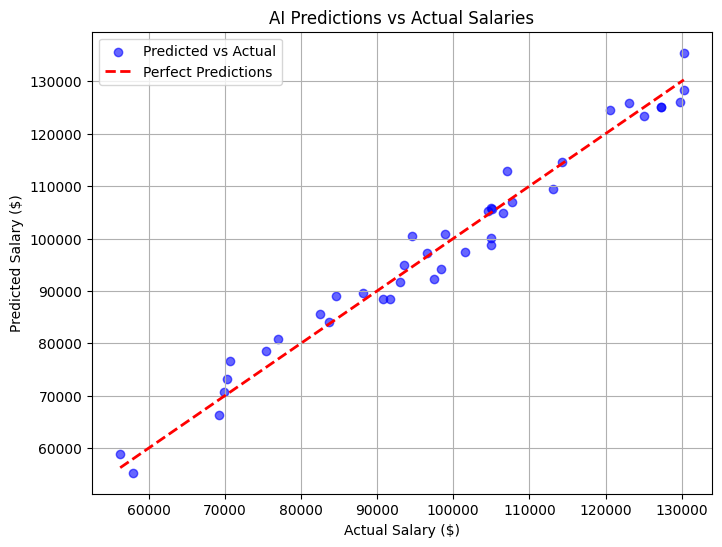

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# STEP 5: PREDICT A CUSTOM SALARY
# ==========================================
print("=== CUSTOM SALARY PREDICTOR ===")

# Define details for a hypothetical new employee:
# Change these numbers to test different scenarios!
my_experience = 5.5   # 5 and a half years of experience
my_job_tier = 2       # Mid-level tier (1 = Junior, 2 = Mid, 3 = Senior)
my_education = 1      # Master's degree (0 = Bachelor's, 1 = Master's, 2 = PhD)

# Put the custom inputs into the correct shape for the AI model
custom_data = pd.DataFrame({
    'YearsExperience': [my_experience],
    'JobTier': [my_job_tier],
    'EducationLevel': [my_education]
})

# Have the trained AI calculate the predicted salary
predicted_result = model.predict(custom_data)
print(f"Predicted Salary for an employee with {my_experience} years experience, ")
print(f"Job Tier {my_job_tier}, and Education Level {my_education}: ")
print(f"👉 ${predicted_result[0]:,.2f}\n")
print("-" * 50)

# ==========================================
# STEP 6: VISUALIZE ACCURACY WITH A GRAPH
# ==========================================
plt.figure(figsize=(8, 6))

# Plot the real salaries vs what the AI guessed
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')

# Draw a perfect diagonal line representing 100% ideal accuracy
perfect_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Predictions')

plt.title('AI Predictions vs Actual Salaries')
plt.xlabel('Actual Salary ($)')
plt.ylabel('Predicted Salary ($)')
plt.legend()
plt.grid(True)
plt.show()
